In [1]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# **Metode Numerik untuk Masalah Nilai Awal (Numerical Methods for Initial Value Problems)**

Metode numerik untuk sistem ODE (Ordinary Differential Equations) yang merupakan *masalah nilai awal* dengan bentuk umum:

$$
\frac{\text{d} \vec{u}}{\text{d}t} = \vec{f}(t, \vec{u}), \quad \vec{u}(0) = \vec{u}_0
$$

Keterangan:
- $\vec{u}(t)$ adalah vektor keadaan (state vector)
- $\vec{f}(t, \vec{u})$ adalah fungsi bernilai vektor yang mengatur pertumbuhan atau perubahan $\vec{u}$ terhadap waktu  
- $\vec{u}(0)$ adalah kondisi awal pada waktu $t = 0$

Bahwa fungsi ruas kanan $\vec{f}$ sebenarnya bisa merupakan hasil dari **diskretisasi ruang suatu PDE**, yaitu berupa sebuah sistem persamaan.

#### **Contoh: Peluruhan Radioaktif Sederhana**
Peluruhan radioaktif sederhana adalah model fisik yang bisa ditulis dan diselesaikan sebagai IVP.

IVP = kerangka matematisnya

Peluruhan radioaktif = contoh kasusnya

$\vec{u} = [c]$

$$
\frac{\text{d} c}{\text{d}t} = -\lambda c \quad c(0) = c_0
$$

yang memiliki solusi dalam bentuk:
$$
c(t) = c_0 e^{-\lambda t}
$$

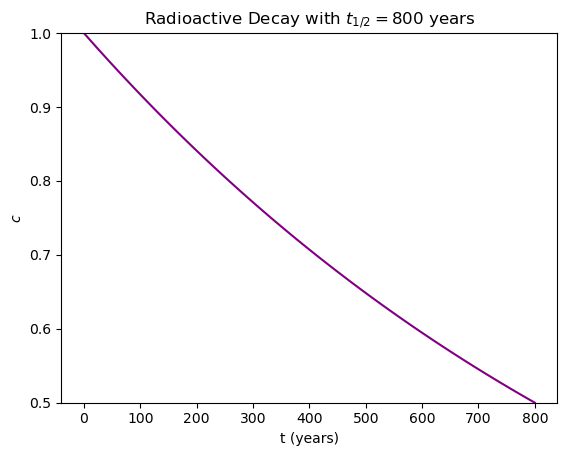

In [2]:
# Membuat array waktu dari 0 sampai 800 tahun (100 titik data)
t = numpy.linspace(0.0, 800.0, 100)

# Nilai awal konsentrasi
c_0 = 1.0

# Waktu paruh (tahun)
t_half = 800.0

# Menghitung konstanta peluruhan (lambda = ln(2)/t_half)
decay_constant = numpy.log(2.0) / t_half

# Membuat figure (area grafik)
fig = plt.figure()

# Membuat satu subplot (1 baris, 1 kolom, posisi ke-1)
axes = fig.add_subplot(1, 1, 1)

# Plot kurva peluruhan eksponensial: c(t) = c0 * exp(-lambda * t)
axes.plot(t, c_0 * numpy.exp(-decay_constant * t), color='purple')

# Memberi judul grafik
axes.set_title("Radioactive Decay with $t_{1/2} = 800$ years")

# Label sumbu x (waktu)
axes.set_xlabel('t (years)')

# Label sumbu y (konsentrasi)
axes.set_ylabel('$c$')

# Membatasi tampilan sumbu y (agar fokus di bagian atas)
axes.set_ylim((0.5, 1.0))

# Menampilkan grafik
plt.show()

#### **Contoh: Peluruhan radioaktif kompleks (atau sistem kimia)**
Rantai peluruhan dari satu spesies ke spesies lainnya

$$\begin{aligned}
    \frac{\text{d} c_1}{\text{d}t} &= -\lambda_1 c_1 \\
    \frac{\text{d} c_2}{\text{d}t} &= \lambda_1 c_1 - \lambda_2 c_2 \\
    \frac{\text{d} c_3}{\text{d}t} &= \lambda_2 c_2 - \lambda_3 c_3
\end{aligned}$$

$$\frac{\text{d} \vec{u}}{\text{d}t} = \frac{\text{d}}{\text{d}t}\begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix} = 
\begin{bmatrix} 
    -\lambda_1 & 0 & 0 \\
    \lambda_1 & -\lambda_2 & 0 \\
    0 & \lambda_2 & -\lambda_3
\end{bmatrix} \begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix}$$

$$\frac{\text{d} \vec{u}}{\text{d}t} = A \vec{u}$$

Untuk sistem persamaan seperti ini, solusi umum dari ODE adalah eksponensial matriks:

$$\vec{u}(t) = e^{A t} \vec{u}_0$$

## **Keberadaan dan Keunikan Solusi**

Salah satu langkah penting sebelum mempelajari metode numerik untuk masalah ODE IVP adalah memahami perilaku solusi, apakah solusi tersebut ada, dan apakah solusi tersebut mungkin unik.

### **Sistem Linear**

Untuk ODE linear, kita memiliki sistem umum:
$$
u'(t) = A(t)\, u + g(t)
$$
di mana $A$ adalah matriks yang bergantung pada waktu dan $g$ adalah sebuah vektor. Perlu dicatat bahwa sistem linear selalu memiliki solusi yang unik. Hal ini karena bentuknya linear, sehingga tidak terjadi “percabangan solusi” seperti pada beberapa sistem non-linear.

Jika $g(t) = 0$ untuk semua $t$, maka ODE disebut *homogen*. Jika matriks $A$ tidak bergantung pada waktu (konstan), maka sistem tersebut juga disebut *otonom*. Solusi dari ODE ini adalah:
$$
u(t) = u(t_0)\, e^{A(t - t_0)}.
$$
Penjelasannya: eksponensial matriks $e^{A(t - t_0)}$ berperan sebagai “penggerak” solusi dari kondisi awal $u(t_0)$ ke waktu $t$. Ini mirip dengan solusi skalar $e^{kt}$ pada persamaan diferensial biasa, tetapi diperluas ke bentuk matriks.

Dalam kasus di mana $g(t) \neq 0$ untuk semua $t$, ODE disebut *tak homogen*. Kita dapat menggunakan prinsip Duhamel, yang menyatakan bahwa:
$$
u(t) = u(t_0)\, e^{A(t - t_0)} + \int_{t_0}^{t} e^{A(t - \tau)} g(\tau)\, d\tau.
$$

Penjelasannya:
- Suku pertama $u(t_0)e^{A(t-t_0)}$ adalah solusi dari bagian homogen (tanpa gaya luar).
- Suku integral menggambarkan pengaruh “gaya luar” $g(t)$ terhadap sistem sepanjang waktu dari $t_0$ hingga $t$.
- Setiap kontribusi $g(\tau)$ pada waktu $\tau$ “dipropagasikan” ke waktu $t$ بواسطة operator $e^{A(t-\tau)}$.

Operator $e^{A(t-\tau)}$ dapat dipandang sebagai operator solusi untuk ODE homogen, yang memetakan solusi dari waktu $\tau$ ke waktu $t$. Karena itu, bentuk solusi ini memiliki sifat seperti fungsi Green, yaitu mengakumulasi efek dari sumber $g(t)$ sepanjang waktu untuk membentuk solusi total.

### **Eksistensi dan Keunikan Non-linier**

#### **Kontinuitas Lipschitz**

Untuk menggeneralisasi keunikan solusi pada ODE non-linear, diperlukan jenis kekontinuan khusus yang disebut *kontinuitas Lipschitz*. Perhatikan ODE berikut:
$$
u'(t) = f(u,t), \quad \quad \quad u(t_0) = u_0,
$$
kita memerlukan tingkat kehalusan (smoothness) tertentu pada fungsi ruas kanan $f(u,t)$ agar solusi tidak “menyimpang” atau menjadi tidak tunggal.

Kita mengatakan bahwa $f$ bersifat *Lipschitz kontinu* terhadap $u$ pada suatu domain
$$
\Omega = \{(u,t) : |u - u_0| \leq a,\; t_0 \leq t \leq t_1 \}
$$
jika terdapat suatu konstanta $L > 0$ sehingga
$$
|f(u,t) - f(u^\ast, t)| \leq L |u - u^\ast| \quad \quad \forall (u,t), (u^\ast,t) \in \Omega.
$$

Penjelasan:
- Kondisi ini membatasi seberapa cepat $f$ berubah terhadap $u$.
- Secara intuitif, fungsi tidak boleh “terlalu curam” atau berubah drastis dalam jarak kecil.
- Konstanta $L$ disebut *konstanta Lipschitz* dan mengontrol tingkat perubahan tersebut.

Jika $f(u,t)$ terdiferensialkan terhadap $u$ di $\Omega$, yaitu turunan Jacobian $f_u = \partial f / \partial u$ ada dan terbatas, maka kita dapat menuliskan
$$
L = \max_{(u,t) \in \Omega} |f_u(u,t)|.
$$

Batas ini dapat digunakan karena
$$
f(u,t) = f(u^\ast, t) + f_u(v,t)(u-u^\ast)
$$
untuk suatu $v$ yang berada di antara $u$ dan $u^\ast$. Ini merupakan bentuk pendekatan deret Taylor orde pertama, yang menunjukkan bahwa perubahan fungsi dapat diperkirakan secara linear di sekitar titik tertentu.

Dengan adanya sifat Lipschitz pada $f$, kita dapat menjamin bahwa solusi IVP (Initial Value Problem) adalah unik, setidaknya hingga waktu
$$
T = \min(t_1, t_0 + a/S)
$$
dengan
$$
S = \max_{(u,t)\in\Omega} |f(u,t)|.
$$

- Nilai $S$ merupakan batas maksimum laju perubahan solusi $u(t)$.
- Batas waktu $T$ memastikan bahwa solusi tidak keluar dari domain $\Omega$.
- Intinya, kondisi Lipschitz menjamin dua hal penting: eksistensi dan keunikan solusi, setidaknya dalam selang waktu tertentu.

#### **Contoh: Kegagalan Lipschitz (Solusi Tidak Unik)**

Pertimbangkan persamaan diferensial:
$$
u'(t) = u^{1/3}, \quad u(0) = 0
$$

Misalkan:
$$
f(u) = u^{1/3}
$$

Turunan terhadap $u$:
$$
f_u = \frac{1}{3} u^{-2/3}
$$

Perhatikan:
- Saat $u \to 0$, maka $f_u \to \infty$
- Jadi fungsi tidak Lipschitz di sekitar $u = 0$

##### Solusi trivial
$$
u(t) = 0
$$

Solusi $u(t) = 0$ disebut sebagai solusi trivial karena merupakan solusi paling sederhana dari persamaan diferensial yang diberikan. Jika kita substitusikan ke dalam persamaan
$$
u'(t) = u^{1/3},
$$
diperoleh bahwa turunan dari $u(t) = 0$ adalah
$$
u'(t) = 0,
$$
sedangkan ruas kanan menjadi
$$
0^{1/3} = 0.
$$

Maka, kedua ruas persamaan sama, sehingga persamaan diferensial terpenuhi. Selain itu, solusi ini juga memenuhi kondisi awal
$$
u(0) = 0,
$$

##### Solusi non-trivial
Pisahkan variabel:
$$
\frac{du}{u^{1/3}} = dt
$$

Integrasi:
$$
u^{2/3} = \frac{2}{3} t + C
$$

Gunakan kondisi awal:
$$
u(0) = 0 \Rightarrow C = 0
$$

Sehingga:
$$
u(t) = \left(\frac{2}{3} t\right)^{3/2}
$$

Didapat dua solusi:
$$
u(t) = 0
\quad \text{dan} \quad
u(t) = \left(\frac{2}{3} t\right)^{3/2}
$$

##### Solusi Lebih Umum

Untuk sembarang $t_0 \ge 0$:
$$
u(t) =
\begin{cases}
0, & t \leq t_0 \\
\left(\frac{2}{3}(t - t_0)\right)^{3/2}, & t > t_0
\end{cases}
$$

#### **Sistem Persamaan**


Konsep yang serupa untuk kekontinuan Lipschitz juga berlaku pada sistem persamaan dengan menggunakan suatu norma tertentu $||\cdot||$. Dikatakan bahwa $f$ bersifat Lipschitz jika terdapat konstanta $L$ sehingga:
$$
||f(u,t) - f(u^\ast,t)|| \leq L \, ||u - u^\ast||
$$
untuk semua $(u,t)$ dan $(u^\ast,t)$ dalam domain
$$
\Omega = \{(u,t) : ||u-u_0|| \leq a,\; t_0 \leq t \leq t_1 \}.
$$

Artinya, jarak antara nilai fungsi $f$ untuk dua titik tidak boleh melebihi konstanta $L$ dikali jarak antara kedua titik tersebut dalam norma yang digunakan.

Pada sistem persamaan, variabel $u$ umumnya berbentuk vektor, sehingga diperlukan norma untuk mengukur besar atau jarak antar vektor. Norma ini bisa berupa norma Euclidean, norma maksimum, atau norma lainnya, tergantung konteks yang digunakan. Syarat Lipschitz dalam bentuk ini memastikan bahwa perubahan kecil pada vektor input $u$ hanya menghasilkan perubahan yang terbatas pada output $f(u,t)$. Dengan kata lain, fungsi tidak berubah secara drastis atau tidak stabil. Hal ini sangat penting dalam analisis sistem ODE karena menjamin bahwa solusi yang diperoleh tidak hanya ada, tetapi juga unik dan stabil terhadap perubahan kondisi awal. Selain itu, meskipun Lipschitz didefinisikan terhadap suatu norma tertentu, dalam ruang berdimensi hingga semua norma bersifat ekuivalen, sehingga jika suatu fungsi Lipschitz dalam satu norma, maka sifat kekontinuannya tetap berlaku dalam norma lainnya.


### **Skema Langkah Dasar (Basic Stepping Schemes)**

Melihat kembali pembahasan kita tentang diferensiasi numerik, kita dapat mendekati turunan menggunakan beda hingga:
$$
\frac{u(t + \Delta t) - u(t)}{\Delta t} = f(t, u)
$$
Namun, kita masih perlu menentukan bagaimana mengevaluasi suku $f(t, u)$ tersebut.

Mari kita lihat dari sudut pandang integrasi (kuadratur), dengan mengintegralkan kedua ruas:

$$\begin{aligned}
\int^{t + \Delta t}_t \frac{\text{d} u}{\text{d}\tilde{t}} d\tilde{t} &= \int^{t + \Delta t}_t f(t, u) d\tilde{t} \\ ~ \\
u(t + \Delta t) - u(t) &= \Delta t ~f(t, u(t)) \\ ~ \\
\frac{u(t + \Delta t) - u(t)}{\Delta t} &= f(t, u(t))
\end{aligned}$$

di mana pada ruas kanan kita menggunakan aturan kuadratur sisi kiri (*left-sided quadrature rule*), yaitu mengambil nilai fungsi di titik awal interval.

Untuk menyederhanakan notasi, kita definisikan:
$$
t_0 = 0 \quad \quad t_1 = t_0 + \Delta t \quad \quad t_n = t_{n-1} + \Delta t = n \Delta t + t_0
$$

$$
U^0 = u(t_0) \quad \quad U^1 = u(t_1) \quad \quad U^n = u(t_n)
$$

Sehingga skema dapat dituliskan sebagai:
$$
\frac{U^{n+1} - U^n}{\Delta t} = f(t_n, U^n)
$$
atau:
$$
U^{n+1} = U^n + \Delta t \, f(t_n, U^n)
$$

Metode ini dikenal sebagai *metode Euler maju* (*forward Euler method*). Pada dasarnya kita mendekati turunan dengan nilai fungsi pada titik waktu $t_n$.

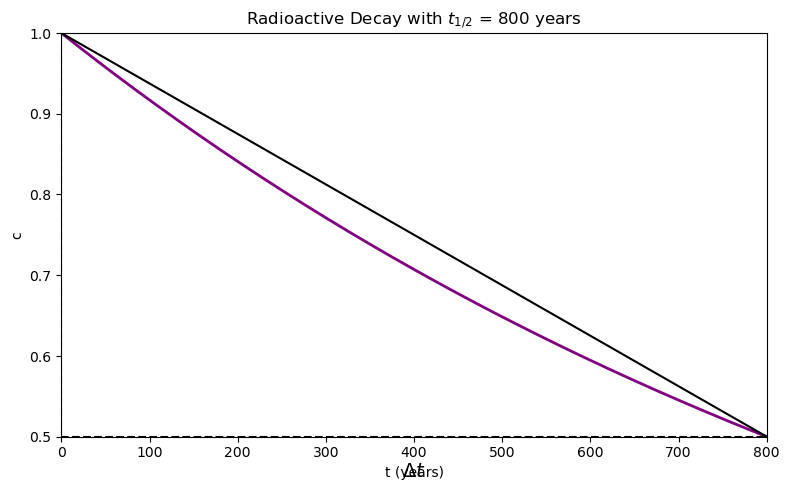

In [3]:
# Parameter
t_half = 800  # paruh waktu (tahun)
c0 = 1.0
t = numpy.linspace(0, 800, 200)  # hanya sampai 800 tahun

# Konstanta peluruhan
lam = numpy.log(2) / t_half

# Fungsi peluruhan
c = c0 * numpy.exp(-lam * t)

# Titik Δt
t1 = 0
t2 = 800
c1 = c0
c2 = c0 * numpy.exp(-lam * t2)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, c, color='purple', linewidth=2)  # garis ungu

# Garis lurus pendekatan
plt.plot([t1, t2], [c1, c2], color='black')

# Garis putus-putus Δt
plt.plot([t1, t1], [c1, c2], 'k--')
plt.plot([t1, t2], [c2, c2], 'k--')

# Label Δt
plt.text((t1 + t2)/2, c2 - 0.05, r'$\Delta t$', ha='center', fontsize=14)

# Label dan judul
plt.xlabel('t (years)')
plt.ylabel('c')
plt.title('Radioactive Decay with $t_{1/2}$ = 800 years')

# Batas sumbu
plt.xlim(0, 800)
plt.ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

Perhatikan di mana kita memperkirakan adanya kesalahan akibat aproksimasi dan bagaimana kesalahan tersebut terwujud dalam contoh di bawah ini.

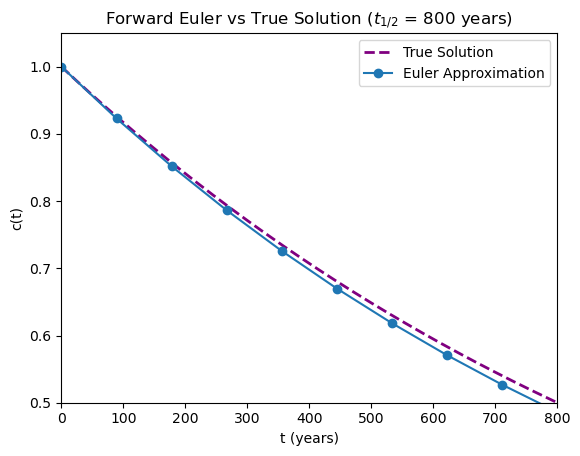

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
c_0 = 1.0
t_half = 800.0
decay_constant = np.log(2.0) / t_half

# Fungsi ODE
f = lambda t, u: -decay_constant * u

# Solusi eksak
t_exact = np.linspace(0.0, 800.0, 200)
u_exact = c_0 * np.exp(-decay_constant * t_exact)

# Metode Euler
t = np.linspace(0.0, 800.0, 10)
delta_t = t[1] - t[0]

U = np.empty(t.shape)
U[0] = c_0

for n, t_n in enumerate(t[:-1]):
    U[n + 1] = U[n] + delta_t * f(t_n, U[n])

# Plot
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# True Solution 
axes.plot(t_exact, u_exact, color='purple', linestyle='--', linewidth=2, label="True Solution")

# Euler
axes.plot(t, U, 'o-', label="Euler Approximation")

# Label
axes.set_title("Forward Euler vs True Solution ($t_{1/2}$ = 800 years)")
axes.set_xlabel("t (years)")
axes.set_ylabel("c(t)")
axes.set_xlim(0, 800)
axes.set_ylim((0.5, 1.05))

axes.legend()
plt.show()

## **Analisis Kesalahan**

#### **Kesalahan Trunkasi (Truncation Errors)**

Kita dapat mendefinisikan kesalahan trunkasi dengan cara yang sama seperti sebelumnya, yaitu dengan memasukkan solusi eksak dari ODE ke dalam persamaan beda (*difference equation*) dan menggunakan ekspansi deret Taylor. Hal yang penting di sini adalah kita menggunakan bentuk persamaan beda yang secara langsung memodelkan turunan, karena jika tidak, hasil yang diperoleh bisa berbeda. 

Misalkan pendekatan beda hingga terhadap turunan didefinisikan sebagai  
$$
D(U^{n+1}, U^n, U^{n-1}, \ldots)
$$, 

maka skema di atas dapat dituliskan sebagai

$$
D(U^{n+1}, U^n, U^{n-1}, \ldots) = F(t^{n+1}, t^n, t^{n-1}, \ldots, U^{n+1}, U^n, U^{n-1}, \ldots)
$$

di mana $F(\cdot)$ sekarang berhubungan dengan evaluasi fungsi \( f(t, u) \). Kemudian, kesalahan trunkasi lokal didefinisikan sebagai

$$
\tau^n = D(u(t^{n+1}), u(t^n), u(t^{n-1}), \ldots) - F(t^{n+1}, t^n, t^{n-1}, \ldots, u(t^{n+1}), u(t^n), u(t^{n-1}), \ldots)
$$

Secara sederhana, kesalahan trunkasi lokal mengukur seberapa jauh skema numerik menyimpang dari persamaan diferensial asli dalam satu langkah waktu, dengan asumsi bahwa nilai sebelumnya adalah solusi eksak. Kesalahan ini muncul karena kita mengganti turunan kontinu dengan pendekatan diskret Selanjutnya, jika diketahui bahwa

$$
\lim_{\Delta t \rightarrow 0} \tau^n = 0
$$

maka persamaan diskret tersebut dikatakan **konsisten**. Artinya, ketika langkah waktu semakin kecil, skema numerik semakin mendekati model kontinu yang sebenarnya. Orde akurasi juga didefinisikan seperti sebelumnya. Jika

$$
|| \tau || \leq C \Delta t^p
$$

secara uniform untuk \( t \in [0, T] \), maka diskretisasi tersebut memiliki akurasi orde ke-\( p \). Semakin besar nilai \( p \), semakin cepat kesalahan berkurang ketika \( \Delta t \) diperkecil. Perlu diperhatikan bahwa suatu metode dikatakan konsisten jika \( p > 0 \).

##### **Analisis Error Metode Forward Euler**

Kita dapat menganalisis error dan orde konvergensi dari metode Forward Euler dengan menggunakan deret Taylor yang dikembangkan di sekitar $ t_n $:
$$
u(t) = u(t_n) + (t - t_n) u'(t_n) + \frac{u''(t_n)}{2} (t - t_n)^2 + \mathcal{O}((t-t_n)^3)
$$

Untuk menghitung *local truncation error* (LTE) pada metode Forward Euler, kita evaluasi deret Taylor tersebut di titik $( t_{n+1} )$, sehingga diperoleh:
$$\begin{aligned}
u(t_{n+1}) &= u(t_n) + (t_{n+1} - t_n) u'(t_n) + \frac{u''(t_n)}{2} (t_{n+1} - t_n)^2 + \mathcal{O}((t_{n+1}-t_n)^3)\\
&= u(t_n) + \Delta t \, f(t_n, u(t_n)) + \frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3)
\end{aligned}$$

Berdasarkan definisi kesalahan trunkasi, kita dapat menggunakan hasil ekspansi Taylor di atas untuk memperoleh:
$$\begin{aligned}
\tau^n &= \frac{u(t_{n+1}) - u(t_n)}{\Delta t} - f(t_n, u(t_n)) \\
&= \frac{1}{\Delta t} \left [u(t_n) + \Delta t \, f(t_n, u(t_n)) + \frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3) - u(t_n) - \Delta t \, f(t_n, u(t_n)) \right ]\\
&= \frac{1}{\Delta t} \left [ \frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3) \right ] \\
&= \frac{u''(t_n)}{2} \Delta t + \mathcal{O}(\Delta t^2)
\end{aligned}$$

Secara interpretasi, hasil ini menunjukkan bahwa kesalahan trunkasi lokal berbanding lurus dengan $ \Delta t $. Hal ini berarti bahwa pendekatan Forward Euler hanya menggunakan informasi kemiringan (turunan pertama) di titik awal $ t_n $, sehingga belum mampu menangkap kelengkungan solusi yang direpresentasikan oleh turunan kedua $ u''(t_n) $. Akibatnya, muncul error yang sebanding dengan ukuran langkah waktu. Dengan kata lain, semakin kecil nilai $ \Delta t $, semakin kecil pula kesalahan yang terjadi, tetapi penurunannya bersifat linear. Oleh karena itu, metode Forward Euler memiliki orde akurasi satu (first order accurate). Karena kesalahan akan menuju nol saat $ \Delta t \rightarrow 0 $, metode ini juga dikatakan konsisten.

## **Metode Deret Taylor**

Sebuah metode deret Taylor dapat diturunkan dengan melakukan substitusi langsung fungsi ruas kanan $f(t, u)$ beserta turunan-turunannya yang sesuai ke dalam ekspansi deret Taylor untuk $u(t_{n+1})$.

Untuk metode orde ke-$p$, kita mempertimbangkan deret Taylor hingga orde tersebut dan mengganti semua turunan dari $u$ dengan turunan dari $f$. Untuk kasus umum, diperoleh:

$$
\begin{aligned}
u(t_{n+1}) = u(t_n) + \Delta t \, u'(t_n) + \frac{\Delta t^2}{2} u''(t_n) + \frac{\Delta t^3}{6} u'''(t_n) + \cdots + \frac{\Delta t^p}{p!} u^{(p)}(t_n)
\end{aligned}
$$

Ekspresi ini memuat turunan $u$ hingga orde ke-$p$. Selanjutnya, turunan-turunan tersebut diganti dengan turunan yang sesuai dari $f$, yang selalu satu orde lebih rendah dibanding turunan $u$ (sesuai dengan ODE asal):

$$
u^{(p)}(t_n) = f^{(p-1)}(t_n, u(t_n))
$$

Sehingga diperoleh metode:

$$
u(t_{n+1}) = u(t_n) + \Delta t f(t_n, u(t_n)) + \frac{\Delta t^2}{2} f'(t_n, u(t_n)) + \frac{\Delta t^3}{6} f''(t_n, u(t_n)) + \cdots + \frac{\Delta t^p}{p!} f^{(p-1)}(t_n, u(t_n)).
$$

Kelemahan metode ini:
- Harus menurunkan metode baru untuk setiap fungsi $f$
- Memerlukan turunan $f$ hingga orde $p-1$

### **Metode Deret Taylor Orde 2**

Kita menginginkan suku hingga orde dua, sehingga perlu menurunkan persamaan $u' = f(t, u)$ satu kali untuk mendapatkan $u'' = f'(t, u)$.

Turunannya adalah:

$$
\begin{aligned}
u(t_{n+1}) &= u(t_n) + \Delta t \, u'(t_n) + \frac{\Delta t^2}{2} u''(t_n) \\
&= u(t_n) + \Delta t f(t_n, u(t_n)) + \frac{\Delta t^2}{2} f'(t_n, u(t_n))
\end{aligned}
$$

atau dalam bentuk diskrit:

$$
U^{n+1} = U^n + \Delta t f(t_n, U^n) + \frac{\Delta t^2}{2} f'(t_n, U^n).
$$

## **Metode Runge-Kutta**

Salah satu cara untuk menurunkan penyelesai ODE orde tinggi adalah dengan menghitung *tahapan perantara* (intermediate stages). Metode ini bukan merupakan metode *multi-step* karena tetap hanya memerlukan informasi dari satu langkah waktu saat ini, tetapi meningkatkan orde akurasi dengan menambahkan *tahapan* (*stages*).
Metode dengan pendekatan seperti ini disebut sebagai metode Runge-Kutta.

Ide utama metode Runge-Kutta adalah memperkirakan nilai solusi di masa depan dengan menggabungkan beberapa evaluasi fungsi $f(t, u)$ dalam satu langkah waktu. Setiap *stage* memberikan perkiraan kemiringan (slope), kemudian semua kemiringan tersebut digabungkan untuk menghasilkan solusi yang lebih akurat.

Sebagai contoh:
- Metode Euler hanya menggunakan satu slope (orde 1)
- Metode Runge-Kutta orde 2 menggunakan dua slope
- Metode Runge-Kutta orde 4 (RK4) menggunakan empat slope dan merupakan yang paling populer

Dengan menambahkan lebih banyak *stage*, metode Runge-Kutta dapat mencapai akurasi tinggi tanpa harus menggunakan langkah waktu sebelumnya seperti pada metode multi-step.

#### **Contoh: Metode Runge-Kutta Dua Tahap**

Ide dasar, gunakan pendekatan awal untuk menghitung nilai sementara, lalu gunakan nilai tersebut untuk update akhir.

$$
\begin{aligned}
U^* &= U^n + \frac{1}{2} \Delta t \, f(U^n) \\
U^{n+1} &= U^n + \Delta t \, f(U^*)
\end{aligned}
$$

Gunakan hubungan:

$$
f(u(t_n)) = u'(t_n)
$$

Sehingga pendekatan fungsi menjadi:

$$
f\left(u(t_n) + \frac{1}{2} \Delta t u'(t_n)\right)
= u'(t_n) + \frac{1}{2} \Delta t u''(t_n) + \mathcal{O}(\Delta t^2)
$$

Hitung galat pemotongan:

$$
\begin{aligned}
\tau^n 
&= \frac{1}{\Delta t} \Big[ u(t_n) + \Delta t f(U^*) \\
&\quad - (u(t_n) + \Delta t u'(t_n) + \tfrac{1}{2}\Delta t^2 u''(t_n)) \Big] \\
&= \mathcal{O}(\Delta t^2)
\end{aligned}
$$

Jadi metode ini berorde dua.

#### **Contoh: Metode Runge-Kutta Empat Tahap**

Metode Runge-Kutta Empat Tahap (RK4) adalah metode numerik untuk menyelesaikan persamaan diferensial biasa yang menggunakan empat pendekatan kemiringan (slope) dalam satu langkah. Metode ini lebih akurat karena menggabungkan informasi dari awal, tengah, dan akhir interval.

$$
\begin{aligned}
Y_1 &= f(U^n) \\
Y_2 &= f\left(U^n + \frac{1}{2} \Delta t \, Y_1 \right) \\
Y_3 &= f\left(U^n + \frac{1}{2} \Delta t \, Y_2 \right) \\
Y_4 &= f\left(U^n + \Delta t \, Y_3 \right) \\
U^{n+1} &= U^n + \frac{\Delta t}{6}(Y_1 + 2Y_2 + 2Y_3 + Y_4)
\end{aligned}
$$ 

Metode ini memiliki akurasi orde 4, sehingga memberikan hasil yang sangat mendekati solusi eksak.ap.

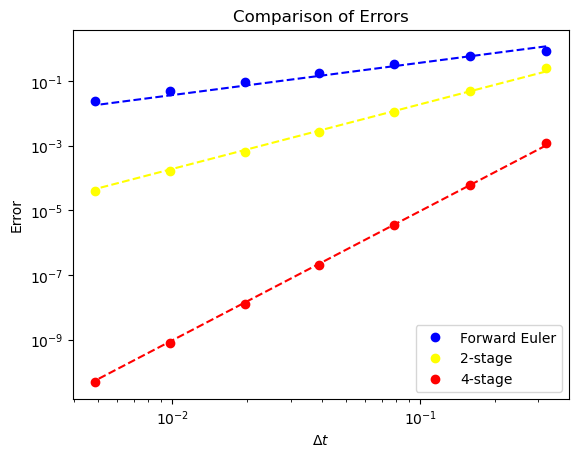

In [23]:
# Bandingkan akurasi antara metode Euler dan Runge-Kutta
import numpy as np

# Fungsi ODE: mendefinisikan model u' = -u
def f(t, u):
    return -u

# Fungsi solusi eksak: u(t) = e^{-t}
def u_exact(t):
    return np.exp(-t)

# Fungsi metode Euler: pendekatan numerik orde 1
def euler_method(t, dt):
    U = np.empty(t.shape)
    U[0] = 1.0
    for n, t_n in enumerate(t[:-1]):
        U[n+1] = U[n] + dt * f(t_n, U[n])
    return U

# Fungsi Runge-Kutta orde 2 (RK2)
def rk2_method(t, dt):
    U = np.empty(t.shape)
    U[0] = 1.0
    for n, t_n in enumerate(t[:-1]):
        U_star = U[n] + 0.5 * dt * f(t_n, U[n])
        U[n+1] = U[n] + dt * f(t_n, U_star)
    return U

# Fungsi Runge-Kutta orde 4 (RK4)
def rk4_method(t, dt):
    U = np.empty(t.shape)
    U[0] = 1.0
    for n, t_n in enumerate(t[:-1]):
        Y1 = f(t_n, U[n])
        Y2 = f(t_n + 0.5*dt, U[n] + 0.5*dt*Y1)
        Y3 = f(t_n + 0.5*dt, U[n] + 0.5*dt*Y2)
        Y4 = f(t_n + dt, U[n] + dt*Y3)

        U[n+1] = U[n] + dt/6.0 * (Y1 + 2*Y2 + 2*Y3 + Y4)
    return U

# Fungsi menghitung error relatif di titik akhir
def compute_error(U, t_f):
    return np.abs(U[-1] - u_exact(t_f)) / np.abs(u_exact(t_f))

# Fungsi membuat garis pembanding orde (untuk cek kemiringan grafik)
def order_line(delta_t, error, order):
    return np.exp(np.log(error) - order * np.log(delta_t))

# Parameter waktu akhir simulasi
t_f = 10.0

# Jumlah langkah (semakin besar → semakin kecil Δt)
num_steps = [2**n for n in range(5, 12)]

# Array untuk menyimpan Δt dan error
delta_t = np.empty(len(num_steps))
error_euler = np.empty(len(num_steps))
error_rk2 = np.empty(len(num_steps))
error_rk4 = np.empty(len(num_steps))

# Perulangan untuk menghitung solusi dan error tiap metode
for i, N in enumerate(num_steps):
    t = np.linspace(0, t_f, N)
    dt = t[1] - t[0]
    delta_t[i] = dt

    # Hitung solusi numerik
    U_euler = euler_method(t, dt)
    U_rk2 = rk2_method(t, dt)
    U_rk4 = rk4_method(t, dt)

    # Hitung error relatif
    error_euler[i] = compute_error(U_euler, t_f)
    error_rk2[i] = compute_error(U_rk2, t_f)
    error_rk4[i] = compute_error(U_rk4, t_f)

# Membuat grafik perbandingan error
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot error masing-masing metode
axes.loglog(delta_t, error_euler, 'o', color='blue', label='Forward Euler')
axes.loglog(delta_t, error_2, 'o', color='yellow', label='2-stage')
axes.loglog(delta_t, error_4, 'o', color='red', label="4-stage")

# Plot garis orde teoritis
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
axes.loglog(delta_t, order_C(delta_t[1], error_euler[1], 1.0) * delta_t**1.0, '--', color='blue')
axes.loglog(delta_t, order_C(delta_t[1], error_2[1], 2.0) * delta_t**2.0, '--', color='yellow')
axes.loglog(delta_t, order_C(delta_t[1], error_4[1], 4.0) * delta_t**4.0, '--', color='red')

# Pengaturan tampilan grafik
axes.legend(loc=4)
axes.set_title("Comparison of Errors")
axes.set_xlabel("$\\Delta t$")
axes.set_ylabel("Error")

# Menampilkan grafik
plt.show()

## **Linear Multi-Step Methods**

Metode multi-langkah (seperti yang diperkenalkan melalui metode *leap-frog*) adalah metode numerik untuk menyelesaikan persamaan diferensial biasa (ODE) yang menggunakan lebih dari satu titik waktu sebelumnya untuk menghitung solusi pada waktu berikutnya. Berbeda dengan metode satu-langkah (misalnya Euler atau Runge-Kutta) yang hanya bergantung pada satu titik sebelumnya, metode ini “mengingat” beberapa langkah sebelumnya sehingga bisa lebih efisien.

Secara umum, metode ini memanfaatkan kombinasi nilai fungsi dan solusi dari beberapa langkah sebelumnya untuk meningkatkan akurasi tanpa harus menambah banyak evaluasi fungsi baru.

##### **Keuntungan**

- Metode deret Taylor memerlukan turunan dari persamaan yang diberikan, yang bisa menjadi rumit dan sulit untuk diimplementasikan  
  Metode multi-langkah tidak memerlukan turunan tingkat tinggi, cukup menggunakan nilai fungsi yang sudah dihitung sebelumnya.

- Metode satu-langkah pada orde tinggi sering kali membutuhkan banyak evaluasi fungsi $f$  
  Metode multi-langkah dapat mencapai orde tinggi dengan jumlah evaluasi fungsi yang lebih sedikit karena memanfaatkan data lama.


##### **Kekurangan**

- Metode ini tidak dapat memulai sendiri (*not self-starting*), artinya memerlukan metode lain untuk menentukan nilai awal  
  Biasanya digunakan metode satu-langkah seperti Runge-Kutta untuk menghasilkan beberapa titik awal sebelum metode multi-langkah digunakan.

- Langkah waktu $\Delta t$ pada metode satu-langkah dapat diubah kapan saja, sedangkan pada metode multi-langkah hal ini jauh lebih kompleks  
  Karena metode ini bergantung pada beberapa langkah sebelumnya, perubahan $\Delta t$ dapat mengganggu konsistensi perhitungan dan memerlukan penyesuaian ulang.


Metode multi-langkah dapat diibaratkan seperti memprediksi posisi berdasarkan “riwayat gerakan”, bukan hanya kondisi saat ini. Dengan melihat beberapa langkah sebelumnya, metode ini dapat memberikan prediksi yang lebih efisien, tetapi menjadi lebih sulit jika kondisi berubah tiba-tiba (misalnya perubahan $\Delta t$).

## **General Linear Multi-Step Methods**

Semua metode multi-langkah linear dapat dituliskan sebagai kombinasi linear dari solusi masa lalu, sekarang, dan masa depan:

$$
\sum^r_{j=0} \alpha_j U^{n+j} = \Delta t \sum^r_{j=0} \beta_j f(U^{n+j}, t_{n+j})
$$

Persamaan ini menyatakan bahwa nilai solusi pada beberapa langkah waktu (diwakili oleh $U^{n+j}$) dikombinasikan secara linear dengan bobot $\alpha_j$, dan dihubungkan dengan evaluasi fungsi $f$ (turunan dari ODE) pada titik-titik tersebut dengan bobot $\beta_j$. Dengan kata lain, metode ini menggunakan informasi dari beberapa titik waktu sekaligus untuk menghitung solusi, sehingga dapat meningkatkan efisiensi dan akurasi dibanding metode satu-langkah.

Jika $\beta_r = 0$, maka metode tersebut bersifat eksplisit (hanya memerlukan nilai pada langkah waktu sebelumnya).  
Sebaliknya, jika $\beta_r \neq 0$, metode menjadi implisit, karena melibatkan nilai yang belum diketahui pada waktu $t_{n+r}$ sehingga perlu diselesaikan (biasanya dengan metode iteratif).

Perlu diperhatikan bahwa koefisien-koefisien tersebut tidak unik, karena kedua ruas persamaan dapat dikalikan dengan suatu konstanta tanpa mengubah bentuk solusi. Dalam praktiknya, biasanya digunakan normalisasi dengan menetapkan $\alpha_r = 1$ agar bentuk persamaan menjadi lebih sederhana dan konsisten untuk analisis maupun implementasi.


## **Metode Adams**

Persamaan umum metode Adams ditulis sebagai:

$$
U^{n+r} = U^{n+r-1} + \Delta t \sum^r_{j=0} \beta_j f(U^{n+j})
$$

Semua metode ini memiliki $\alpha_r = 1$, $\alpha_{r-1} = -1$, dan $\alpha_j = 0$ untuk $j < r-1$. Perbedaan metode Adams ditentukan oleh cara evaluasi fungsi $f$, yang memengaruhi nilai koefisien $\beta_j$.
Metode Adams dapat dipahami sebagai pendekatan integral dari ODE dengan menggunakan interpolasi nilai $f$. Bukan hanya memakai satu slope seperti metode Euler, metode ini menggabungkan beberapa slope dari waktu sebelumnya sehingga hasilnya lebih akurat. Namun, semakin banyak langkah yang digunakan (nilai $r$ lebih besar), metode menjadi lebih efisien tetapi juga membutuhkan lebih banyak data awal dan pengelolaan yang lebih kompleks.

### **Metode Adams-Bashforth**

Metode Adams-Bashforth adalah metode eksplisit yang memaksimalkan orde akurasi untuk sejumlah langkah $r$. Hal ini dilakukan dengan melihat deret Taylor dan memilih koefisien $\beta_j$ untuk menghilangkan sebanyak mungkin suku dalam deret Taylor. Metode ini termasuk dalam kategori multi-step method, karena menggunakan beberapa nilai sebelumnya untuk menghitung nilai berikutnya.

$$
U_{n+1} = U_n + \Delta t \sum_{j=0}^{r-1} \beta_j f(U_{n-j})
$$

##### **Contoh:**
$$
\begin{aligned}
    \text{1-step:} & & U_{n+1} &= U_n + \Delta t\, f(U_n) \\
    \text{2-step:} & & U_{n+2} &= U_{n+1} + \frac{\Delta t}{2} \left( -f(U_n) + 3 f(U_{n+1}) \right) \\
    \text{3-step:} & & U_{n+3} &= U_{n+2} + \frac{\Delta t}{12} \left( 5 f(U_n) - 16 f(U_{n+1}) + 23 f(U_{n+2}) \right) \\
    \text{4-step:} & & U_{n+4} &= U_{n+3} + \frac{\Delta t}{24} \left( -9 f(U_n) + 37 f(U_{n+1}) - 59 f(U_{n+2}) + 55 f(U_{n+3}) \right)
\end{aligned}
$$

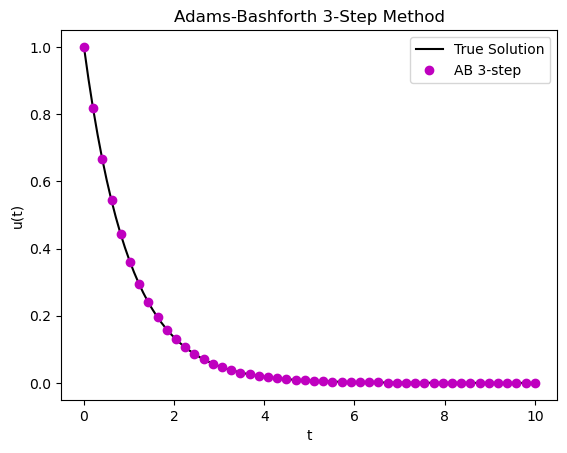

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fungsi ODE
f = lambda t, u: -u  # Definisi turunan u'(t) = -u

# Solusi eksak untuk perbandingan
t_exact = np.linspace(0.0, 10.0, 100)  # Array waktu dengan 100 titik
u_exact = np.exp(-t_exact)             # Solusi analitik u(t) = e^(-t)

# Grid numerik
N = 50                                  # Jumlah titik untuk metode numerik
t = np.linspace(0, 10.0, N)            # Array waktu numerik
delta_t = t[1] - t[0]                   # Panjang langkah (Δt)
U = np.empty(t.shape)                   # Array kosong untuk menyimpan solusi numerik

# Kondisi awal
U[0] = 1.0                              # Nilai awal u(0) = 1

# Step ke-1 (Runge-Kutta 2 tahap untuk memulai metode multi-step)
k1 = f(t[0], U[0])                      # Evaluasi f di awal langkah
k2 = f(t[0] + delta_t, U[0] + delta_t * k1)  # Evaluasi f di akhir langkah (prediksi)
U[1] = U[0] + (delta_t / 2.0) * (k1 + k2)    # Rata-rata slope (RK2)

# Step ke-2 (Runge-Kutta 2 tahap untuk langkah berikutnya)
k1 = f(t[1], U[1])
k2 = f(t[1] + delta_t, U[1] + delta_t * k1)
U[2] = U[1] + (delta_t / 2.0) * (k1 + k2)

# Adams-Bashforth 3-step (metode multi-step explicit)
for n in range(0, len(t) - 3):
    # Rumus AB 3-step: U[n+3] = U[n+2] + Δt/12 * (23*f[n+2] - 16*f[n+1] + 5*f[n])
    U[n+3] = U[n+2] + delta_t/12.0 * (
        5.0 * f(t[n], U[n])
        - 16.0 * f(t[n+1], U[n+1])
        + 23.0 * f(t[n+2], U[n+2])
    )

# Plot hasil
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t_exact, u_exact, 'k', label="True Solution")  # Plot solusi analitik
axes.plot(t, U, 'mo', label="AB 3-step")               # Plot solusi numerik Adams-Bashforth 3-step

axes.set_title("Adams-Bashforth 3-Step Method")        # Judul plot
axes.set_xlabel("t")                                   # Label sumbu-x
axes.set_ylabel("u(t)")                                # Label sumbu-y
axes.legend(loc=1)                                     # Menampilkan legenda di kanan atas

plt.show()                                             # Tampilkan plot

## Metode Adams-Moulton

Metode **Adams-Moulton** adalah versi *implisit* dari metode Adams-Bashforth.  
Karena metode ini memiliki satu parameter tambahan yang dapat digunakan, yaitu $\beta_r$, maka metode ini umumnya memiliki orde akurasi satu tingkat lebih tinggi dibandingkan metode pasangannya. Metode ini termasuk dalam kategori multi-step method dan memerlukan penyelesaian persamaan implisit pada setiap langkah.

$$
U_{n+1} = U_n + \Delta t \sum_{j=0}^{r} \beta_j f(U_{n+1-j})
$$

#### **Contoh:**

$$
\begin{aligned}
    \text{1-langkah:} &  & U_{n+1} &= U_n + \frac{\Delta t}{2} \left( f(U_n) + f(U_{n+1}) \right) \\
    \text{2-langkah:} &  & U_{n+2} &= U_{n+1} + \frac{\Delta t}{12} \left( -f(U_n) + 8f(U_{n+1}) + 5f(U_{n+2}) \right) \\
    \text{3-langkah:} &  & U_{n+3} &= U_{n+2} + \frac{\Delta t}{24} \left( f(U_n) - 5f(U_{n+1}) + 19f(U_{n+2}) + 9f(U_{n+3}) \right) \\
    \text{4-langkah:} &  & U_{n+4} &= U_{n+3} + \frac{\Delta t}{720} \left( -19 f(U_n) + 106 f(U_{n+1}) -264 f(U_{n+2}) + 646 f(U_{n+3}) + 251 f(U_{n+4}) \right)
\end{aligned}
$$


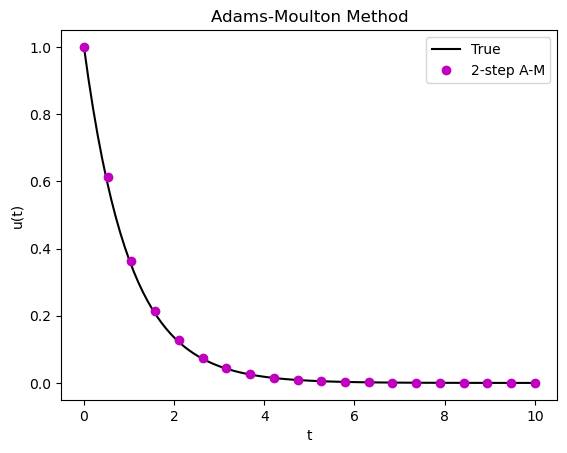

In [24]:
# Definisi persamaan diferensial
decay_constant = 1.0  # Konstanta peluruhan untuk u' = -decay_constant * u
f = lambda t, u: -decay_constant * u  # Fungsi turunan u'(t)

# Solusi analitik untuk perbandingan
t_exact = numpy.linspace(0.0, 10.0, 100)  # Array waktu dengan 100 titik
u_exact = numpy.exp(-t_exact)             # Solusi analitik u(t) = e^(-t)

# Persiapan untuk metode numerik
N = 20                                    # Jumlah titik untuk metode numerik
t = numpy.linspace(0, 10.0, N)           # Array waktu numerik
delta_t = t[1] - t[0]                     # Panjang langkah (Δt)
U = numpy.empty(t.shape)                  # Array kosong untuk solusi numerik
U[0] = 1.0                                # Nilai awal u(0) = 1

# Inisialisasi langkah pertama
U[1] = U[0] + 0.5 * delta_t * f(t[0], U[0])  # Prediksi awal (Euler setengah langkah)
U[1] = U[0] + delta_t * f(t[0], U[1])        # Koreksi Adams-Moulton 2-step

# Persiapan konstanta integrasi
integration_constant = 1.0 / (1.0 + 5.0 * decay_constant * delta_t / 12.0)
# Fungsi: mempercepat perhitungan U[n+2] agar tidak menghitung ulang setiap iterasi

# Loop metode 2-step Adams-Moulton
for n in range(t.shape[0] - 2):
    # Rumus 2-step Adams-Moulton:
    # U[n+2] = (U[n+1] + (Δt*decay_constant/12) * (U[n] - 8*U[n+1])) * integration_constant
    U[n+2] = (U[n+1] + decay_constant * delta_t / 12.0 * (U[n] - 8.0 * U[n+1])) * integration_constant

# Plot hasil
fig = plt.figure()                         # Membuat figure baru
axes = fig.add_subplot(1, 1, 1)           # Membuat subplot tunggal

axes.plot(t_exact, u_exact, 'k', label="True")  # Plot solusi analitik
axes.plot(t, U, 'mo', label="2-step A-M")      # Plot solusi numerik Adams-Moulton

axes.set_title("Adams-Moulton Method")         # Judul plot
axes.set_xlabel("t")                           # Label sumbu-x
axes.set_ylabel("u(t)")                        # Label sumbu-y
axes.legend(loc=1)                             # Menampilkan legend di kanan atas

plt.show()                                     # Tampilkan plot

### **Galat Pemotongan (Truncation Error) untuk Metode Multi-Step**

Kita dapat kembali mencari galat trunkasi secara umum untuk metode multi-langkah linear:

$$
\begin{aligned}
\tau^n &= \frac{1}{\Delta t} \left [\sum^r_{j=0} \alpha_j u(t_{n+j}) - \Delta t \sum^r_{j=0} \beta_j f(t_{n+j}, u(t_{n+j})) \right ]
\end{aligned}
$$

Dengan menggunakan ekspansi deret Taylor di sekitar $t_n$, diperoleh:

$$
\begin{aligned}
u(t_{n+j}) &= u(t_n) + j \Delta t\, u'(t_n) + \frac{1}{2} (j \Delta t)^2 u''(t_n) + \mathcal{O}(\Delta t^3) \\
u'(t_{n+j}) &= u'(t_n) + j \Delta t\, u''(t_n) + \frac{1}{2} (j \Delta t)^2 u'''(t_n) + \mathcal{O}(\Delta t^3)
\end{aligned}
$$

Sehingga:

$$
\begin{aligned}
\tau^n &= \frac{1}{\Delta t}\left( \sum^r_{j=0} \alpha_j\right) u(t_{n}) 
+ \left(\sum^r_{j=0} (j\alpha_j - \beta_j)\right) u'(t_n) \\
&\quad + \Delta t \left(\sum^r_{j=0} \left (\frac{1}{2}j^2 \alpha_j - j \beta_j \right) \right) u''(t_n) \\
&\quad + \cdots
\end{aligned}
$$


- Galat pemotongan ($\tau^n$) mengukur kesalahan metode numerik dalam satu langkah dibandingkan solusi eksak.
- Deret Taylor digunakan untuk membandingkan metode numerik dengan solusi sebenarnya.
- Koefisien $\alpha_j$ dan $\beta_j$ menentukan jenis metode multi-langkah yang digunakan.


Metode dikatakan *konsisten* jika:

$$
\sum^r_{j=0} \alpha_j = 0
$$

$$
\sum^r_{j=0} j \alpha_j = \sum^r_{j=0} \beta_j
$$

Maknanya:
- Syarat pertama memastikan metode benar untuk solusi konstan.
- Syarat kedua memastikan metode benar untuk solusi linear.
- Jika terpenuhi, galat akan mulai dari orde lebih tinggi terhadap $\Delta t$, sehingga metode menjadi akurat saat $\Delta t \to 0$.

<>:60: SyntaxWarning: invalid escape sequence '\D'
<>:60: SyntaxWarning: invalid escape sequence '\D'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20576\1544856433.py:60: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta t$")


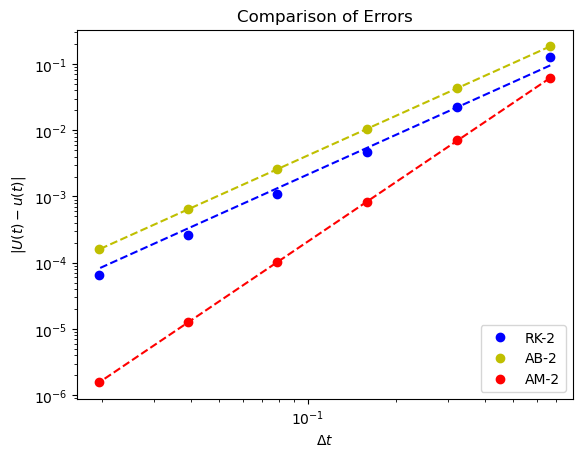

In [25]:
# Definisi ODE dan solusi analitik
f = lambda t, u: -u
u_exact = lambda t: numpy.exp(-t)

# Parameter simulasi
t_f = 10.0
num_steps = [2**n for n in range(4,10)]
delta_t = numpy.empty(len(num_steps))
error_rk = numpy.empty(len(num_steps))
error_ab = numpy.empty(len(num_steps))
error_am = numpy.empty(len(num_steps))

# Loop simulasi untuk berbagai Δt
for (i, N) in enumerate(num_steps):
    t = numpy.linspace(0, t_f, N)
    delta_t[i] = t[1] - t[0]
    
    # RK-2 untuk inisialisasi dan solusi
    U_rk = numpy.empty(t.shape)
    U_rk[0] = 1.0
    for n in range(t.shape[0]-1):
        U_rk[n+1] = U_rk[n] + 0.5 * delta_t[i] * f(t[n], U_rk[n])
        U_rk[n+1] = U_rk[n] + delta_t[i] * f(t[n], U_rk[n+1])
    
    # Adams-Bashforth 2-step
    U_ab = numpy.empty(t.shape)
    U_ab[:2] = U_rk[:2]
    for n in range(t.shape[0] - 2):
        U_ab[n+2] = U_ab[n + 1] + delta_t[i] / 2.0 * (-f(t[n], U_ab[n]) + 3.0 * f(t[n+1], U_ab[n+1]))
    
    # Adams-Moulton 2-step
    U_am = numpy.empty(t.shape)
    U_am[:2] = U_rk[:2]
    decay_constant = 1.0
    integration_constant = 1.0 / (1.0 + 5.0 * decay_constant * delta_t[i] / 12.0)
    for n in range(t.shape[0] - 2):
        U_am[n+2] = (U_am[n+1] + decay_constant * delta_t[i] / 12.0 * (U_am[n] - 8.0 * U_am[n+1])) * integration_constant
    
    # Hitung error untuk tiap metode
    error_rk[i] = numpy.linalg.norm(delta_t[i] * (U_rk - u_exact(t)), ord=1)
    error_ab[i] = numpy.linalg.norm(delta_t[i] * (U_ab - u_exact(t)), ord=1)
    error_am[i] = numpy.linalg.norm(delta_t[i] * (U_am - u_exact(t)), ord=1)

# Plot error vs. Δt
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.loglog(delta_t, error_rk, 'bo', label='RK-2')
axes.loglog(delta_t, error_ab, 'yo', label='AB-2')
axes.loglog(delta_t, error_am, 'ro', label="AM-2")

# Garis referensi order metode
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
axes.loglog(delta_t, order_C(delta_t[1], error_rk[1], 2.0) * delta_t**2.0, '--b')
axes.loglog(delta_t, order_C(delta_t[1], error_ab[1], 2.0) * delta_t**2.0, '--y')
axes.loglog(delta_t, order_C(delta_t[1], error_am[1], 3.0) * delta_t**3.0, '--r')

axes.legend(loc=4)
axes.set_title("Comparison of Errors")
axes.set_xlabel("$\Delta t$")
axes.set_ylabel("$|U(t) - u(t)|$")

plt.show()

### **Metode Predictor-Corrector**

Salah satu cara untuk menyederhanakan metode Adams-Moulton sehingga tidak memerlukan evaluasi implisit adalah dengan memperkirakan nilai implisit tersebut menggunakan metode eksplisit. Metode ini disebut predictor-corrector, karena metode eksplisit digunakan untuk memberikan *prediksi* awal solusi, kemudian langkah *korektor* digunakan untuk memperbaiki hasil tersebut agar lebih akurat.

Secara umum, metode ini dilakukan dalam dua tahap: pertama menghitung pendekatan awal (predictor), lalu menggunakan hasil tersebut untuk memperbaiki solusi (corrector). Pendekatan ini membuat perhitungan lebih mudah dibanding metode implisit murni, tetapi tetap menjaga akurasi yang baik.

##### **Contoh: Metode Adams-Bashforth-Moulton Satu Langkah**

Gunakan metode Adams-Bashforth satu langkah untuk memprediksi nilai $U^{n+1}$, lalu gunakan metode Adams-Moulton untuk mengoreksinya:

- Predictor
$$
\hat{U}^{n+1} = U^n + \Delta t \, f(U^n)
$$

- Corrector 
$$
U^{n+1} = U^n + \frac{1}{2} \Delta t \left( f(U^n) + f(\hat{U}^{n+1}) \right)
$$

Metode ini memiliki orde akurasi dua (second order accurate).

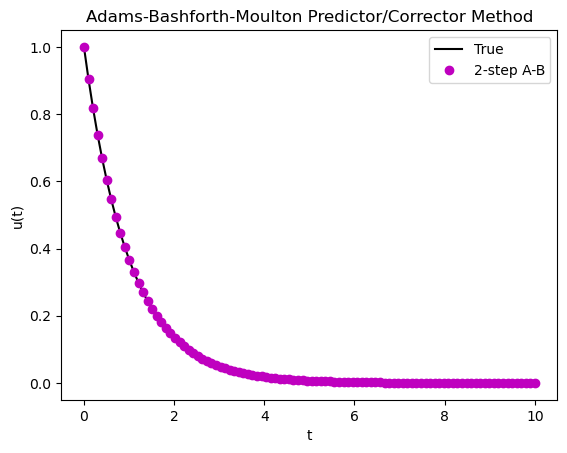

In [ ]:
# Definisi ODE dan solusi analitik
f = lambda t, u: -u                     # Fungsi turunan u'(t) = -u
t_exact = numpy.linspace(0.0, 10.0, 100)
u_exact = numpy.exp(-t_exact)           # Solusi analitik

# Grid numerik
N = 100
t = numpy.linspace(0, 10.0, N)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)

# Kondisi awal
U[0] = 1.0

# One-step Adams-Bashforth-Moulton (Predictor-Corrector)
for n in range(t.shape[0] - 1):
    # Predictor: Euler eksplisit
    U[n+1] = U[n] + delta_t * f(t[n], U[n])
    # Corrector: Trapezoidal (Adams-Moulton)
    U[n+1] = U[n] + 0.5 * delta_t * (f(t[n], U[n]) + f(t[n+1], U[n+1]))

# Plot solusi
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t_exact, u_exact, 'k', label="True")  # Plot solusi analitik
axes.plot(t, U, 'mo', label="2-step A-B")      # Plot solusi numerik ABM

axes.set_title("Adams-Bashforth-Moulton Predictor/Corrector Method")
axes.set_xlabel("t")
axes.set_ylabel("u(t)")
axes.legend(loc=1)

plt.show()